In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Load data
df = pd.read_csv("AirQuality.csv", sep=';', low_memory=False)

# 2️⃣ Drop completely empty columns
df = df.dropna(axis=1, how='all')

# 3️⃣ Remove duplicate header rows
df = df[df['Date'] != 'Date']

# 4️⃣ Replace commas with dots
df = df.replace(',', '.', regex=True)

# 5️⃣ Convert numeric columns
for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 6️⃣ Create Datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H.%M.%S',
                                errors='coerce')

# 7️⃣ Drop rows with invalid datetime
df = df.dropna(subset=['Datetime'])

# 8️⃣ Set Datetime as index
df.set_index('Datetime', inplace=True)

# 9️⃣ Drop old Date and Time
df.drop(columns=['Date', 'Time'], inplace=True, errors='ignore')

# 🔟 Resample to daily averages
df_daily = df.resample('D').mean()



In [4]:
print("✅ Daily data shape:", df_daily.shape)
print(df_daily.head())


✅ Daily data shape: (391, 13)
               CO(GT)  PT08.S1(CO)    NMHC(GT)   C6H6(GT)  PT08.S2(NMHC)  \
Datetime                                                                   
2004-03-10   1.966667  1316.500000   86.500000   8.450000     912.333333   
2004-03-11  -6.187500  1244.166667  104.500000   7.979167     851.958333   
2004-03-12 -14.095833  1281.666667  141.500000  12.129167    1008.291667   
2004-03-13  -5.750000  1330.666667  139.250000  10.916667     992.833333   
2004-03-14  -5.966667  1361.125000  116.958333   9.637500     943.916667   

               NOx(GT)  PT08.S3(NOx)     NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
Datetime                                                                      
2004-03-10  132.000000   1167.333333  108.833333   1545.500000  1096.000000   
2004-03-11  130.041667   1277.250000   87.375000   1522.833333   885.250000   
2004-03-12  142.583333   1101.875000   89.916667   1627.291667  1084.375000   
2004-03-13  168.416667    993.208333  105.

In [5]:
df_daily.to_csv("AirQuality_daily_clean.csv")


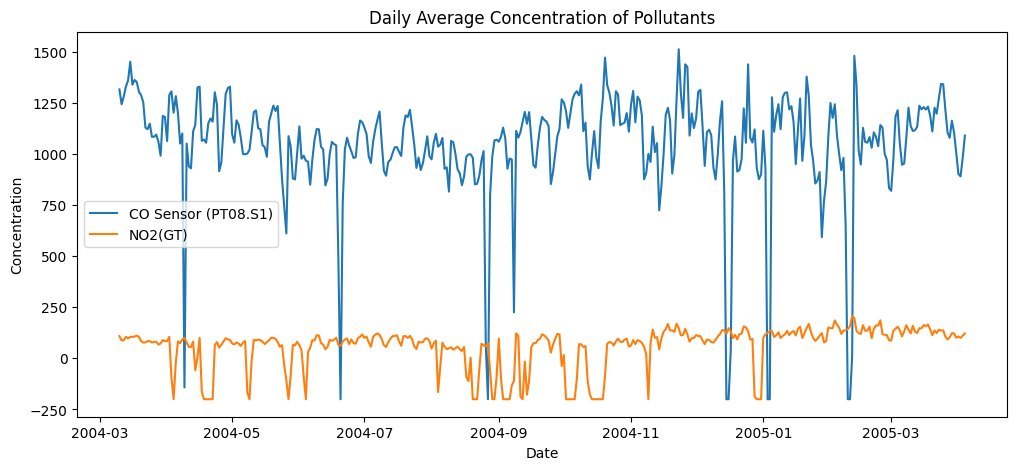

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df_daily.index, df_daily['PT08.S1(CO)'], label='CO Sensor (PT08.S1)')
plt.plot(df_daily.index, df_daily['NO2(GT)'], label='NO2(GT)')
plt.title("Daily Average Concentration of Pollutants")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.show()


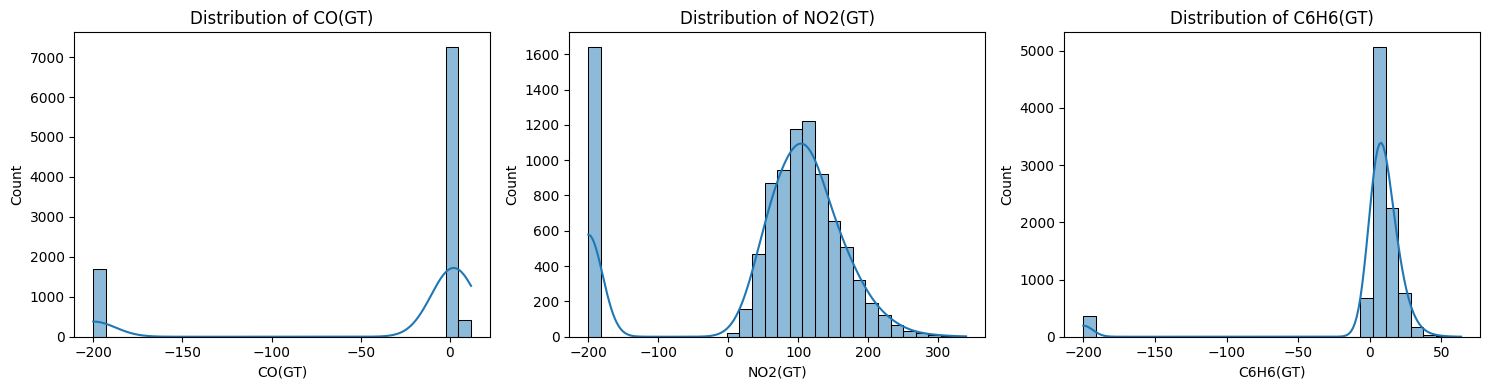

In [8]:
import seaborn as sns  

# Example histogram plot
pollutants = ['CO(GT)', 'NO2(GT)', 'C6H6(GT)']

plt.figure(figsize=(15,4))
for i, col in enumerate(pollutants, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


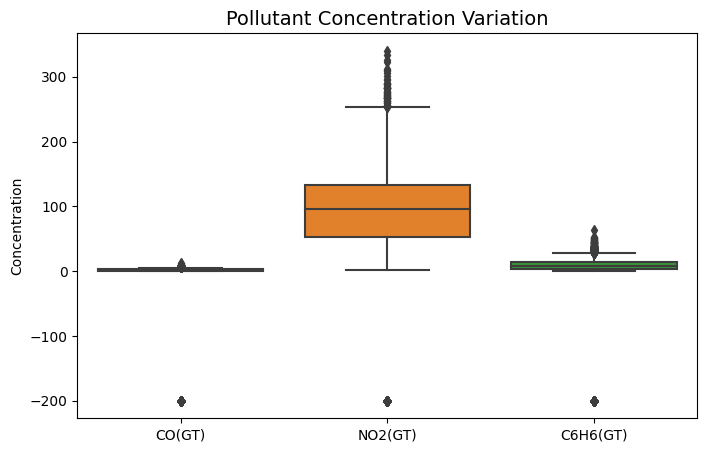

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['CO(GT)', 'NO2(GT)', 'C6H6(GT)']])
plt.title("Pollutant Concentration Variation", fontsize=14)
plt.ylabel("Concentration")
plt.show()
